# 모델 평가와 반복 검증

## 학습 목표

1. 교차검증의 원리와 K-Fold 수식을 이해하고 적용할 수 있음
2. 과대적합/과소적합을 학습 곡선으로 진단하고 대응할 수 있음
3. 정밀도, 재현율, F1, ROC-AUC 등 상황에 맞는 평가 지표를 선택할 수 있음

## 실습 데이터: 반도체 웨이퍼 품질 검사 데이터

### 반도체 제조 공정 개요

```
웨이퍼 투입 → 증착(Deposition) → 노광(Lithography) → 식각(Etching) → 세정(Cleaning) → 검사 → 패키징
```

각 공정에서 **온도, 압력, 가스 유량, 시간** 등 수십 개의 파라미터가 실시간으로 모니터링되며, 이 데이터를 분석하여 **불량 웨이퍼를 사전 예측**하는 것이 품질 관리의 핵심임.

### 데이터셋 구성

| 구분 | 변수명 | 설명 | 단위 |
|------|--------|------|------|
| 증착 공정 | chamber_temp | 챔버 온도 | °C |
| | chamber_pressure | 챔버 압력 | Torr |
| | gas_flow_1 | 반응가스1 유량 | sccm |
| | gas_flow_2 | 반응가스2 유량 | sccm |
| | rf_power | RF 파워 | W |
| | deposition_time | 증착 시간 | 초 |
| 식각 공정 | etch_temp | 식각 온도 | °C |
| | etch_pressure | 식각 압력 | mTorr |
| | etch_time | 식각 시간 | 초 |
| | etch_power | 식각 파워 | W |
| 세정 공정 | clean_temp | 세정 온도 | °C |
| | clean_time | 세정 시간 | 초 |
| 측정값 | thickness | 박막 두께 | nm |
| | uniformity | 균일도 | % |
| | particle_count | 파티클 수 | 개 |
| **타겟** | **quality** | **품질 판정** | **1=양품, 0=불량** |

### 품질 관리 시나리오

**상황**: 경기도 이천의 A반도체 공장에서 웨이퍼 품질 예측 시스템을 구축하려고 함

**목표**: 공정 파라미터를 기반으로 최종 품질(양품/불량)을 예측하여 불량 웨이퍼를 조기에 검출

**기대 효과**:
- 불량품 조기 발견으로 후공정 비용 절감
- 공정 이상 징후 실시간 모니터링
- 수율(Yield) 향상을 통한 원가 절감

## 환경 설정

In [ ]:
# 필요 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# 경고 메시지 숨김
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # macOS
# plt.rcParams['font.family'] = 'NanumGothic'  # Linux (Colab)
plt.rcParams['axes.unicode_minus'] = False

# 시각화 스타일
plt.style.use('seaborn-v0_8-whitegrid')

# 재현성을 위한 시드 고정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('환경 설정 완료')

## 데이터 생성 및 로딩

실제 반도체 공정 데이터의 특성을 반영한 시뮬레이션 데이터를 생성함.

In [2]:
# 반도체 웨이퍼 품질 데이터 시뮬레이션 생성
np.random.seed(RANDOM_STATE)
n_samples = 3000

# 공정 파라미터 생성
data = {
    # 증착(Deposition) 공정
    'chamber_temp': np.random.normal(450, 15, n_samples),
    'chamber_pressure': np.random.normal(3.5, 0.3, n_samples),
    'gas_flow_1': np.random.normal(200, 20, n_samples),
    'gas_flow_2': np.random.normal(150, 15, n_samples),
    'rf_power': np.random.normal(800, 50, n_samples),
    'deposition_time': np.random.normal(120, 10, n_samples),
    
    # 식각(Etching) 공정
    'etch_temp': np.random.normal(25, 3, n_samples),
    'etch_pressure': np.random.normal(50, 5, n_samples),
    'etch_time': np.random.normal(90, 8, n_samples),
    'etch_power': np.random.normal(500, 40, n_samples),
    
    # 세정(Cleaning) 공정
    'clean_temp': np.random.normal(70, 5, n_samples),
    'clean_time': np.random.normal(300, 30, n_samples),
    
    # 측정값
    'thickness': np.random.normal(100, 5, n_samples),
    'uniformity': np.random.normal(2.0, 0.5, n_samples),
    'particle_count': np.random.poisson(5, n_samples),
}

df = pd.DataFrame(data)

# 불량 조건 정의 (실제 공정 불량 원인 반영)
defect_prob = np.zeros(n_samples)
defect_prob += np.where(np.abs(df['chamber_temp'] - 450) > 20, 0.3, 0)  # 온도 이탈
defect_prob += np.where(np.abs(df['chamber_pressure'] - 3.5) > 0.5, 0.25, 0)  # 압력 이탈
defect_prob += np.where(df['particle_count'] > 8, 0.4, 0)  # 파티클 과다
defect_prob += np.where(df['uniformity'] > 3.0, 0.35, 0)  # 균일도 불량
defect_prob += np.where(np.abs(df['thickness'] - 100) > 8, 0.3, 0)  # 두께 이탈

defect_prob = np.clip(defect_prob, 0, 0.95)
df['quality'] = np.where(np.random.random(n_samples) < defect_prob, 0, 1)

print(f'데이터 생성 완료: {len(df):,}건')
print(f'특성 변수: {len(df.columns)-1}개')

데이터 생성 완료: 3,000건
특성 변수: 15개


In [3]:
# 기본 통계 확인
print('데이터 기본 정보')
print('=' * 60)
print(f'전체 샘플 수: {len(df):,}건')
print(f'특성 변수 수: {len(df.columns)-1}개')
print(f'결측치: {df.isnull().sum().sum()}개')

print('\n품질 분포')
print('-' * 40)
quality_counts = df['quality'].value_counts().sort_index()
print(f'양품 (1): {quality_counts[1]:,}건 ({quality_counts[1]/len(df)*100:.1f}%)')
print(f'불량 (0): {quality_counts[0]:,}건 ({quality_counts[0]/len(df)*100:.1f}%)')
print(f'\n불균형 비율: 약 1:{quality_counts[1]/quality_counts[0]:.1f}')

데이터 기본 정보
전체 샘플 수: 3,000건
특성 변수 수: 15개
결측치: 0개

품질 분포
----------------------------------------
양품 (1): 2,575건 (85.8%)
불량 (0): 425건 (14.2%)

불균형 비율: 약 1:6.1


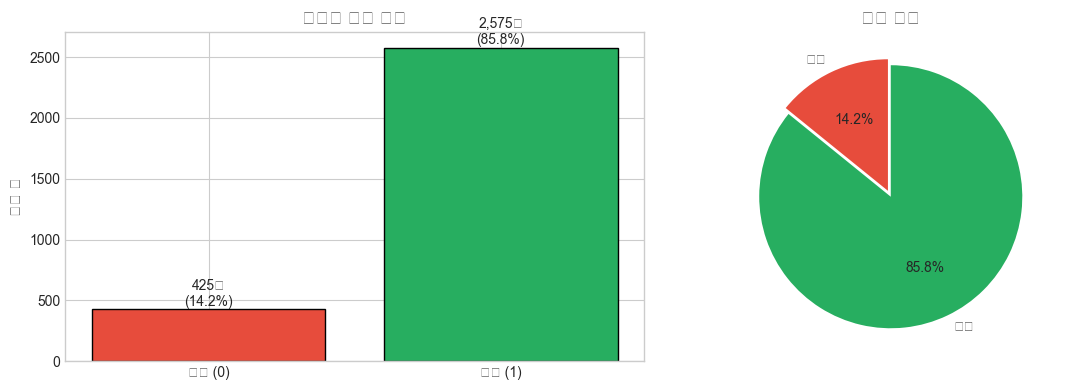


[불균형 데이터 문제]
- 양품이 85.8%로 다수 클래스
- 모든 샘플을 양품으로 예측해도 정확도가 높게 나옴
- 하지만 불량 검출이 핵심 목표이므로 정확도만으로는 부족함


In [4]:
# 품질 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 막대 그래프
colors = ['#e74c3c', '#27ae60']
bars = axes[0].bar(['불량 (0)', '양품 (1)'], quality_counts.values, color=colors, edgecolor='black')
axes[0].set_ylabel('샘플 수', fontsize=11)
axes[0].set_title('웨이퍼 품질 분포', fontsize=13)

for bar, val in zip(bars, quality_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{val:,}건\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)

# 파이 차트
axes[1].pie(quality_counts.values, labels=['불량', '양품'], colors=colors,
           autopct='%1.1f%%', startangle=90, explode=[0.05, 0])
axes[1].set_title('품질 비율', fontsize=13)

plt.tight_layout()
plt.show()

print('\n[불균형 데이터 문제]')
print(f'- 양품이 {quality_counts[1]/len(df)*100:.1f}%로 다수 클래스')
print('- 모든 샘플을 양품으로 예측해도 정확도가 높게 나옴')
print('- 하지만 불량 검출이 핵심 목표이므로 정확도만으로는 부족함')

In [5]:
# 특성 변수와 타겟 변수 분리
feature_cols = [col for col in df.columns if col != 'quality']
X = df[feature_cols].values
y = df['quality'].values

print(f'특성 행렬 X: {X.shape}')
print(f'타겟 벡터 y: {y.shape}')
print(f'\n특성 변수 목록:')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {col}')

특성 행렬 X: (3000, 15)
타겟 벡터 y: (3000,)

특성 변수 목록:
   1. chamber_temp
   2. chamber_pressure
   3. gas_flow_1
   4. gas_flow_2
   5. rf_power
   6. deposition_time
   7. etch_temp
   8. etch_pressure
   9. etch_time
  10. etch_power
  11. clean_temp
  12. clean_time
  13. thickness
  14. uniformity
  15. particle_count


# Part 1: 교차검증의 원리

## 1.1 왜 교차검증이 필요한가?

### 실제 사례: A반도체 품질 예측 시스템 구축

**상황**: 품질관리팀에서 머신러닝 모델을 학습시키고 테스트했더니 정확도 92%가 나왔음

**문제**: 실제 생산라인에 적용했더니 성능이 85%로 떨어짐. 왜 이런 일이 발생했을까?

**원인**: 단순 Train/Test 분할의 한계

### 단순 분할의 문제점

| 문제 | 설명 |
|------|------|
| 분할 의존성 | 어떤 데이터가 테스트에 포함되느냐에 따라 결과가 달라짐 |
| 우연의 영향 | 테스트 세트가 우연히 쉬운/어려운 샘플일 수 있음 |
| 신뢰도 문제 | 한 번의 평가로는 모델의 진짜 성능을 알 수 없음 |

In [6]:
# 단순 분할의 불안정성 시연
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

print('단순 Train/Test 분할의 불안정성 시연')
print('=' * 60)
print('동일한 모델을 10번 다르게 분할하여 평가:\n')

scores_simple = []
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=i, stratify=y
    )
    model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    scores_simple.append(score)
    print(f'  분할 {i+1:2d}: 정확도 = {score:.4f} ({score*100:.2f}%)')

print('\n' + '-' * 60)
print(f'최소: {min(scores_simple):.4f}, 최대: {max(scores_simple):.4f}')
print(f'범위: {(max(scores_simple)-min(scores_simple))*100:.2f}%p')
print('\n[결론] 같은 모델인데 분할 방식에 따라 성능이 달라짐!')

단순 Train/Test 분할의 불안정성 시연
동일한 모델을 10번 다르게 분할하여 평가:

  분할  1: 정확도 = 0.8683 (86.83%)
  분할  2: 정확도 = 0.8600 (86.00%)
  분할  3: 정확도 = 0.8567 (85.67%)
  분할  4: 정확도 = 0.8550 (85.50%)
  분할  5: 정확도 = 0.8683 (86.83%)
  분할  6: 정확도 = 0.8483 (84.83%)
  분할  7: 정확도 = 0.8667 (86.67%)
  분할  8: 정확도 = 0.8617 (86.17%)
  분할  9: 정확도 = 0.8517 (85.17%)
  분할 10: 정확도 = 0.8483 (84.83%)

------------------------------------------------------------
최소: 0.8483, 최대: 0.8683
범위: 2.00%p

[결론] 같은 모델인데 분할 방식에 따라 성능이 달라짐!


## 1.2 K-Fold 교차검증

### 핵심 아이디어

데이터를 K개로 나누고, 각각을 한 번씩 테스트로 사용하여 K번 평가한 뒤 평균을 냄

### K-Fold 분할 구조 (K=5 예시)

```
Fold 1: [테스트] [학습 ] [학습 ] [학습 ] [학습 ]  → 점수₁
Fold 2: [학습 ] [테스트] [학습 ] [학습 ] [학습 ]  → 점수₂
Fold 3: [학습 ] [학습 ] [테스트] [학습 ] [학습 ]  → 점수₃
Fold 4: [학습 ] [학습 ] [학습 ] [테스트] [학습 ]  → 점수₄
Fold 5: [학습 ] [학습 ] [학습 ] [학습 ] [테스트]  → 점수₅

최종 점수 = (점수₁ + 점수₂ + 점수₃ + 점수₄ + 점수₅) / 5
```

### 수학적 정의

**교차검증 점수 (CV Score)**

$$CV_{score} = \frac{1}{K}\sum_{k=1}^{K}Score_k$$

**표준편차 (안정성 지표)**

$$\sigma = \sqrt{\frac{1}{K}\sum_{k=1}^{K}(Score_k - CV_{score})^2}$$

In [7]:
# 수식 계산 예시
print('CV Score 수식 계산 예시')
print('=' * 50)

example_scores = np.array([0.88, 0.91, 0.87, 0.90, 0.89])
K = len(example_scores)

print(f'\n입력: 5개 Fold 점수 = {example_scores}')

# CV Score
cv_score = np.sum(example_scores) / K
print(f'\n[CV Score 계산]')
print(f'CV_score = (1/K) × Σ Score_k')
print(f'        = (1/5) × {np.sum(example_scores):.2f}')
print(f'        = {cv_score:.4f}')

# 표준편차
std = np.sqrt(np.mean((example_scores - cv_score)**2))
print(f'\n[표준편차 계산]')
print(f'σ = √[(1/K) × Σ(Score_k - CV_score)²]')
print(f'  = {std:.4f}')

print(f'\n[최종 결과] {cv_score:.4f} ± {std:.4f}')
print(f'해석: 평균 {cv_score*100:.1f}% 정확도, 약 ±{std*100:.1f}%p 변동')

CV Score 수식 계산 예시

입력: 5개 Fold 점수 = [0.88 0.91 0.87 0.9  0.89]

[CV Score 계산]
CV_score = (1/K) × Σ Score_k
        = (1/5) × 4.45
        = 0.8900

[표준편차 계산]
σ = √[(1/K) × Σ(Score_k - CV_score)²]
  = 0.0141

[최종 결과] 0.8900 ± 0.0141
해석: 평균 89.0% 정확도, 약 ±1.4%p 변동


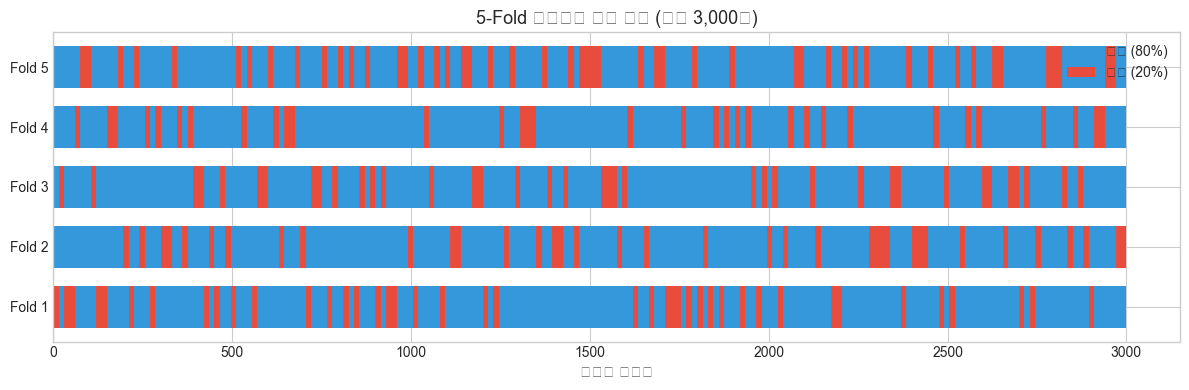

In [8]:
# K-Fold 분할 시각화
from sklearn.model_selection import KFold

n_splits = 5
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(12, 4))

for fold_idx, (train_idx, test_idx) in enumerate(kfold.split(X)):
    # 시각화를 위해 샘플링
    indices = np.zeros(len(X))
    indices[test_idx] = 1
    
    step = max(1, len(X) // 200)
    for i in range(0, len(X), step):
        color = '#e74c3c' if indices[i] == 1 else '#3498db'
        ax.barh(fold_idx, step, left=i, height=0.7, color=color, edgecolor='none')

ax.set_yticks(range(n_splits))
ax.set_yticklabels([f'Fold {i+1}' for i in range(n_splits)])
ax.set_xlabel('데이터 인덱스', fontsize=11)
ax.set_title(f'5-Fold 교차검증 분할 구조 (전체 {len(X):,}건)', fontsize=13)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='학습 (80%)'),
                   Patch(facecolor='#e74c3c', label='검증 (20%)')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

## 1.3 cross_val_score 실습

In [9]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# 5-Fold 교차검증
model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print('5-Fold 교차검증 결과 (RandomForest)')
print('=' * 50)
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f} ({score*100:.2f}%)')

print('\n' + '-' * 50)
print(f'평균: {cv_scores.mean():.4f}')
print(f'표준편차: {cv_scores.std():.4f}')
print(f'\n최종 결과: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

5-Fold 교차검증 결과 (RandomForest)
  Fold 1: 0.8633 (86.33%)
  Fold 2: 0.8600 (86.00%)
  Fold 3: 0.8617 (86.17%)
  Fold 4: 0.8483 (84.83%)
  Fold 5: 0.8717 (87.17%)

--------------------------------------------------
평균: 0.8610
표준편차: 0.0075

최종 결과: 0.8610 ± 0.0075


In [ ]:
# 단순 분할 vs 교차검증 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 단순 분할
axes[0].bar(range(1, 11), scores_simple, color='lightcoral', edgecolor='black')
axes[0].axhline(y=np.mean(scores_simple), color='red', linestyle='--', lw=2,
               label=f'평균: {np.mean(scores_simple):.4f}')
axes[0].set_xlabel('시도 번호')
axes[0].set_ylabel('정확도')
axes[0].set_title(f'단순 분할 (10회)\n표준편차: {np.std(scores_simple):.4f}')
axes[0].legend()

# 교차검증
axes[1].bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black')
axes[1].axhline(y=cv_scores.mean(), color='blue', linestyle='--', lw=2,
               label=f'평균: {cv_scores.mean():.4f}')
axes[1].set_xlabel('Fold 번호')
axes[1].set_ylabel('정확도')
axes[1].set_title(f'5-Fold 교차검증\n표준편차: {cv_scores.std():.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print('[비교 결과]')
print(f'단순 분할: {np.mean(scores_simple):.4f} ± {np.std(scores_simple):.4f}')
print(f'교차검증:  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('\n교차검증이 더 안정적이고 신뢰할 수 있는 성능 추정을 제공함')

---

## 1.4 여러 모델 교차검증 비교

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 여러 모델 정의
models = {
    'DecisionTree': DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5))
    ])
}

print('여러 모델 5-Fold 교차검증 비교')
print('=' * 60)

results = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    results.append({'model': name, 'mean': scores.mean(), 'std': scores.std(), 'scores': scores})
    print(f'{name:20s}: {scores.mean():.4f} ± {scores.std():.4f}')

best = max(results, key=lambda x: x['mean'])
print('\n' + '=' * 60)
print(f'최고 성능 모델: {best["model"]} ({best["mean"]:.4f})')

In [ ]:
# 모델 비교 시각화
fig, ax = plt.subplots(figsize=(10, 5))

model_names = [r['model'] for r in results]
model_scores = [r['scores'] for r in results]

bp = ax.boxplot(model_scores, labels=model_names, patch_artist=True)

colors = plt.cm.Set3(np.linspace(0, 1, len(model_names)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, r in enumerate(results):
    ax.scatter(i+1, r['mean'], color='red', s=80, zorder=5, marker='D')

ax.set_ylabel('정확도', fontsize=11)
ax.set_title('모델별 5-Fold 교차검증 성능 비교', fontsize=13)
ax.tick_params(axis='x', rotation=15)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='D', color='w', markerfacecolor='red', 
                          markersize=10, label='평균')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

---

# Part 2: 과대적합/과소적합 진단

---

## 2.1 과대적합과 과소적합 이해

### 실제 사례: B반도체 품질 예측 모델

**상황 1 (과소적합)**: 단순한 선형 모델을 사용했더니 학습 데이터에서도 정확도가 75%밖에 안 나옴
- 원인: 모델이 너무 단순해서 복잡한 공정 패턴을 학습하지 못함

**상황 2 (과대적합)**: 복잡한 모델을 사용했더니 학습 데이터에서 99%인데, 새 데이터에서는 80%
- 원인: 모델이 학습 데이터의 노이즈까지 외워버림

### 진단 기준표

| 학습 점수 | 테스트 점수 | 갭 | 진단 | 대응 |
|:--------:|:---------:|:--:|:----:|------|
| 낮음 | 낮음 | 작음 | **과소적합** | 모델 복잡도↑, 특성 추가 |
| 높음 | 높음 | 작음 | **적절** | 모델 채택 |
| 높음 | 낮음 | 큼 | **과대적합** | 정규화, 모델 단순화, 데이터↑ |

In [ ]:
from sklearn.model_selection import train_test_split

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('DecisionTree max_depth별 적합도 진단')
print('=' * 70)
print(f'{"max_depth":>10} {"학습 점수":>12} {"테스트 점수":>12} {"갭":>10} {"진단":>12}')
print('-' * 70)

depth_results = []
for depth in [1, 2, 3, 5, 7, 10, 15, 20, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    gap = train_score - test_score
    
    if train_score < 0.85:
        status = '과소적합'
    elif gap > 0.08:
        status = '과대적합'
    else:
        status = '적절'
    
    depth_str = str(depth) if depth else 'None'
    print(f'{depth_str:>10} {train_score:>12.4f} {test_score:>12.4f} {gap:>10.4f} {status:>12}')
    
    depth_results.append({
        'depth': depth if depth else 50,
        'depth_str': depth_str,
        'train': train_score,
        'test': test_score,
        'gap': gap,
        'status': status
    })

In [ ]:
# 적합도 시각화
fig, ax = plt.subplots(figsize=(10, 5))

depths = range(len(depth_results))
train_scores = [r['train'] for r in depth_results]
test_scores = [r['test'] for r in depth_results]

ax.plot(depths, train_scores, 'o-', label='학습 점수', color='blue', lw=2, ms=8)
ax.plot(depths, test_scores, 'o-', label='테스트 점수', color='orange', lw=2, ms=8)
ax.fill_between(depths, train_scores, test_scores, alpha=0.3, color='red', label='갭')

ax.set_xticks(depths)
ax.set_xticklabels([r['depth_str'] for r in depth_results])
ax.set_xlabel('max_depth', fontsize=11)
ax.set_ylabel('점수', fontsize=11)
ax.set_title('DecisionTree 복잡도에 따른 학습/테스트 점수', fontsize=13)
ax.legend(loc='lower right')
ax.set_ylim(0.75, 1.02)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('[해석]')
print('- depth 작음: 과소적합 (둘 다 낮음)')
print('- depth 큼: 과대적합 (학습만 높고, 갭 큼)')
print('- 중간: 적절 (둘 다 높고, 갭 작음)')

---

## 2.2 학습 곡선 (Learning Curve)

**학습 곡선**은 학습 데이터의 양에 따른 성능 변화를 보여줌

### 해석 방법

| 패턴 | 의미 | 대응 |
|------|------|------|
| 두 곡선 모두 낮고 수렴 | 과소적합 | 모델 복잡도 증가 |
| 학습↑, 검증↓, 큰 갭 | 과대적합 | 더 많은 데이터 필요 |
| 두 곡선 모두 높고 수렴 | 적절 | 모델 채택 |

In [ ]:
from sklearn.model_selection import learning_curve

# 학습 곡선 계산
model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)

train_sizes, train_scores_lc, val_scores_lc = learning_curve(
    model, X, y, cv=5,
    train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    scoring='accuracy', random_state=RANDOM_STATE, n_jobs=-1
)

# 시각화
fig, ax = plt.subplots(figsize=(10, 5))

train_mean = train_scores_lc.mean(axis=1)
train_std = train_scores_lc.std(axis=1)
val_mean = val_scores_lc.mean(axis=1)
val_std = val_scores_lc.std(axis=1)

ax.plot(train_sizes, train_mean, 'o-', label='학습 점수', color='blue', lw=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')

ax.plot(train_sizes, val_mean, 'o-', label='검증 점수', color='orange', lw=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='orange')

ax.set_xlabel('학습 데이터 수', fontsize=11)
ax.set_ylabel('점수', fontsize=11)
ax.set_title('학습 곡선 (Learning Curve)', fontsize=13)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('[학습 곡선 해석]')
print(f'- 최종 학습 점수: {train_mean[-1]:.4f}')
print(f'- 최종 검증 점수: {val_mean[-1]:.4f}')
print(f'- 최종 갭: {train_mean[-1] - val_mean[-1]:.4f}')
print('- 두 곡선이 수렴하고 있어 적절한 모델로 판단됨')

---

# Part 3: 평가 지표 심화

---

## 3.1 정확도(Accuracy)의 한계

### 실제 사례: C반도체 불량 검출 시스템

**상황**: 품질관리팀이 만든 모델의 정확도가 84%라고 보고함

**문제**: 실제로 확인해보니 불량 웨이퍼를 거의 검출하지 못함

**원인**: 데이터가 불균형(양품 84%, 불량 16%)이라서, 모든 웨이퍼를 양품으로 예측해도 84% 정확도가 나옴

### 반도체 품질 관리에서의 의미

| 상황 | 비용 | 중요 지표 |
|------|------|----------|
| 불량을 양품으로 잘못 판정 (FN) | 고객 클레임, 신뢰도 하락 | **재현율 (Recall)** |
| 양품을 불량으로 잘못 판정 (FP) | 양품 폐기 비용 | **정밀도 (Precision)** |

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score

print('정확도의 한계 시연')
print('=' * 60)

# 더미 분류기 (항상 다수 클래스 예측)
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

# RandomForest
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print(f'\n테스트 데이터 분포:')
print(f'  양품: {(y_test == 1).sum()}건 ({(y_test == 1).mean()*100:.1f}%)')
print(f'  불량: {(y_test == 0).sum()}건 ({(y_test == 0).mean()*100:.1f}%)')

print('\n' + '-' * 60)
print(f'{"모델":^20} {"정확도":^15} {"불량 검출률":^15}')
print('-' * 60)

# 더미
dummy_acc = accuracy_score(y_test, dummy_pred)
dummy_recall = recall_score(y_test, dummy_pred, pos_label=0)  # 불량(0)이 검출 대상
print(f'{"더미 분류기":^20} {dummy_acc*100:^15.1f}% {dummy_recall*100:^15.1f}%')

# RF
rf_acc = accuracy_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred, pos_label=0)
print(f'{"RandomForest":^20} {rf_acc*100:^15.1f}% {rf_recall*100:^15.1f}%')

print('\n[결론]')
print('- 더미 분류기: 정확도는 높지만 불량을 전혀 검출 못함')
print('- RandomForest: 불량 검출률이 높아 실제로 유용함')
print('- 불균형 데이터에서는 정확도 외에 다른 지표가 필수!')

---

## 3.2 혼동 행렬 (Confusion Matrix)

### 혼동 행렬 구조

|  | 예측: 양품 (1) | 예측: 불량 (0) |
|--|:-------------:|:-------------:|
| **실제: 양품 (1)** | TN | FP |
| **실제: 불량 (0)** | FN | TP |

### 반도체 품질 관리 관점

| 약어 | 의미 | 반도체 예시 | 비용 |
|:----:|------|------------|------|
| TN | 양품→양품 | 양품 웨이퍼를 양품으로 판정 | 없음 |
| TP | 불량→불량 | 불량 웨이퍼를 불량으로 검출 | 없음 |
| FP | 양품→불량 | 양품을 불량으로 오판 | 폐기 비용 |
| FN | 불량→양품 | 불량이 출하됨 | 클레임, 신뢰 하락 |

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 혼동 행렬 계산 (불량=0이 Positive)
cm = confusion_matrix(y_test, rf_pred)

print('혼동 행렬')
print('=' * 50)
print(f'\n{cm}')

# 요소 추출 (불량=0 기준)
TN = cm[1, 1]  # 양품→양품
FP = cm[1, 0]  # 양품→불량
FN = cm[0, 1]  # 불량→양품
TP = cm[0, 0]  # 불량→불량

print(f'\n[불량(0) 기준 분석]')
print(f'  TP (불량 정확 검출): {TP}건')
print(f'  TN (양품 정확 판정): {TN}건')
print(f'  FP (양품→불량 오판): {FP}건 - 폐기 비용 발생')
print(f'  FN (불량→양품 누락): {FN}건 - 품질 사고 위험!')

In [ ]:
# 혼동 행렬 히트맵
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 절대값
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['불량 예측', '양품 예측'],
            yticklabels=['불량 실제', '양품 실제'],
            annot_kws={'size': 14})
axes[0].set_xlabel('예측값', fontsize=11)
axes[0].set_ylabel('실제값', fontsize=11)
axes[0].set_title('혼동 행렬 (절대값)', fontsize=13)

# 비율
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_pct, annot=True, fmt='.1%', cmap='Blues', ax=axes[1],
            xticklabels=['불량 예측', '양품 예측'],
            yticklabels=['불량 실제', '양품 실제'],
            annot_kws={'size': 14})
axes[1].set_xlabel('예측값', fontsize=11)
axes[1].set_ylabel('실제값', fontsize=11)
axes[1].set_title('혼동 행렬 (비율)', fontsize=13)

plt.tight_layout()
plt.show()

---

## 3.3 정밀도, 재현율, F1 점수

### 정밀도 (Precision)

**"불량으로 예측한 것 중 실제 불량의 비율"**

$$Precision = \frac{TP}{TP + FP}$$

→ 높을수록 양품을 불량으로 잘못 판정하는 경우가 적음 (폐기 비용 감소)

### 재현율 (Recall)

**"실제 불량 중 불량으로 검출한 비율"**

$$Recall = \frac{TP}{TP + FN}$$

→ 높을수록 불량 웨이퍼를 놓치지 않음 (품질 사고 예방)

### F1 점수

**정밀도와 재현율의 조화 평균**

$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('정밀도, 재현율, F1 점수 계산 (불량=0 기준)')
print('=' * 60)

# 정밀도
precision = TP / (TP + FP)
print(f'\n[정밀도 (Precision)]')
print(f'Precision = TP / (TP + FP)')
print(f'          = {TP} / ({TP} + {FP})')
print(f'          = {precision:.4f} ({precision*100:.1f}%)')
print(f'해석: 불량 예측 중 {precision*100:.1f}%가 실제 불량')

# 재현율
recall = TP / (TP + FN)
print(f'\n[재현율 (Recall)]')
print(f'Recall = TP / (TP + FN)')
print(f'       = {TP} / ({TP} + {FN})')
print(f'       = {recall:.4f} ({recall*100:.1f}%)')
print(f'해석: 실제 불량 중 {recall*100:.1f}%를 검출')

# F1
f1 = 2 * (precision * recall) / (precision + recall)
print(f'\n[F1 점수]')
print(f'F1 = 2 × (Precision × Recall) / (Precision + Recall)')
print(f'   = {f1:.4f} ({f1*100:.1f}%)')

# sklearn 검증
print(f'\n[sklearn 검증]')
print(f'precision_score: {precision_score(y_test, rf_pred, pos_label=0):.4f}')
print(f'recall_score: {recall_score(y_test, rf_pred, pos_label=0):.4f}')
print(f'f1_score: {f1_score(y_test, rf_pred, pos_label=0):.4f}')

---

## 3.4 ROC 곡선과 AUC

### ROC 곡선이란?

다양한 임계값(threshold)에서 **TPR(재현율)**과 **FPR(위양성률)**의 관계를 나타낸 곡선

- TPR (True Positive Rate) = Recall = TP / (TP + FN)
- FPR (False Positive Rate) = FP / (FP + TN)

### AUC (Area Under Curve)

ROC 곡선 아래 면적. **임계값에 관계없이** 모델의 분류 능력을 평가

| AUC | 해석 |
|:---:|------|
| 1.0 | 완벽한 분류 |
| 0.9+ | 우수 |
| 0.8-0.9 | 좋음 |
| 0.7-0.8 | 보통 |
| 0.5 | 무작위 수준 |

In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# 예측 확률
y_proba = rf.predict_proba(X_test)[:, 0]  # 불량(0) 확률

# ROC 곡선
fpr, tpr, thresholds = roc_curve(y_test, y_proba, pos_label=0)
roc_auc = auc(fpr, tpr)

# 시각화
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.3, color='darkorange')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=11)
ax.set_title('ROC Curve - 웨이퍼 불량 검출', fontsize=13)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'[ROC-AUC 해석]')
print(f'AUC = {roc_auc:.3f}')
print(f'→ 임의의 불량 웨이퍼가 임의의 양품보다 높은 불량 확률을 받을 확률: {roc_auc*100:.1f}%')

In [ ]:
from sklearn.metrics import classification_report

print('Classification Report')
print('=' * 60)
print(classification_report(y_test, rf_pred, target_names=['불량', '양품']))

---

## 3.5 평가 지표 선택 가이드

### 반도체 품질 관리 시나리오별 지표 선택

| 시나리오 | 우선 지표 | 이유 |
|----------|----------|------|
| 고객 클레임 최소화 | **재현율 (Recall)** | 불량 누락 방지가 최우선 |
| 폐기 비용 최소화 | **정밀도 (Precision)** | 양품 오판 감소 |
| 균형 잡힌 성능 | **F1 점수** | 정밀도와 재현율 조화 |
| 전반적 분류 능력 | **ROC-AUC** | 임계값 독립적 평가 |

### 일반적인 지표 선택 기준

| 데이터 특성 | 추천 지표 |
|------------|----------|
| 균형 데이터 | Accuracy |
| 불균형 + 오탐 비용 큼 | Precision |
| 불균형 + 누락 비용 큼 | Recall |
| 불균형 + 균형 필요 | F1 |
| 확률 기반 순위 평가 | ROC-AUC |

---

# 핵심 정리

---

## 수식 요약

| 지표 | 수식 | 의미 |
|------|------|------|
| CV Score | $\frac{1}{K}\sum_{k=1}^{K}Score_k$ | K개 Fold 점수 평균 |
| Precision | $\frac{TP}{TP + FP}$ | 예측 양성 중 실제 양성 |
| Recall | $\frac{TP}{TP + FN}$ | 실제 양성 중 예측 양성 |
| F1 | $2 \times \frac{P \times R}{P + R}$ | 정밀도·재현율 조화평균 |

## 개념 요약

| 개념 | 설명 |
|------|------|
| 교차검증 | K번 평가 후 평균 → 더 신뢰성 있는 성능 추정 |
| 과소적합 | 모델이 너무 단순 → 학습/테스트 모두 낮음 |
| 과대적합 | 모델이 너무 복잡 → 학습만 높고 갭 큼 |
| 학습 곡선 | 데이터 양에 따른 성능 변화 |
| 혼동 행렬 | TP, TN, FP, FN 정리표 |
| ROC-AUC | 임계값 독립적 분류 능력 평가 |

## sklearn 주요 함수

```python
# 교차검증
from sklearn.model_selection import cross_val_score, KFold, learning_curve

# 평가 지표
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score
)
```